In [187]:
# 1)problem statement:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [188]:
#2)Data Collection:
df=pd.read_excel('height_weight_data.xlsx')

In [189]:
#3)EDA:Exploratory Data Analysis:

In [190]:
df.isna().sum()

,0
Sr.no,0
Name,0
Age(yrs),0
Gender,0
Height (cm),7
Weight(kg),6
Health Insurance cover,0
Premium,0


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sr.no                   1676 non-null   int64  
 1   Name                    1676 non-null   object 
 2   Age(yrs)                1676 non-null   float64
 3   Gender                  1676 non-null   object 
 4   Height (cm)             1669 non-null   float64
 5   Weight(kg)              1670 non-null   float64
 6   Health Insurance cover  1676 non-null   int64  
 7   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 104.9+ KB


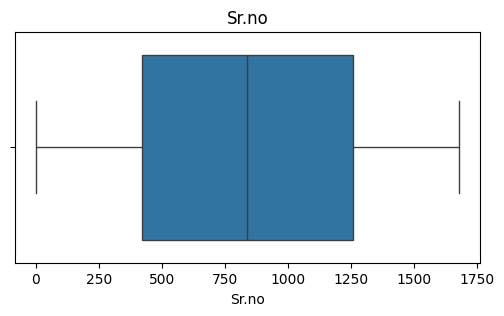

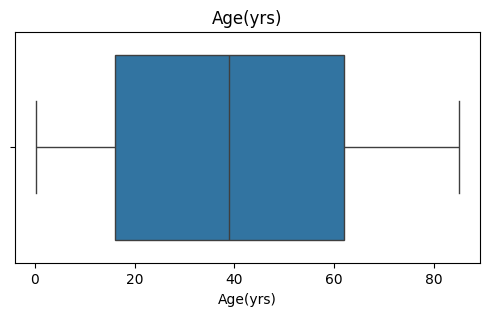

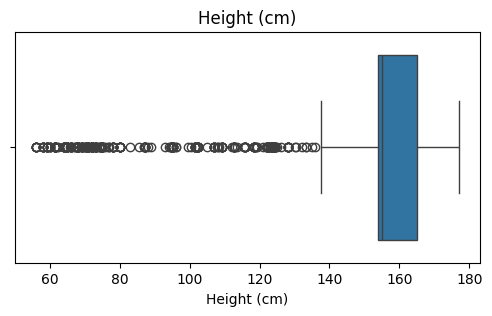

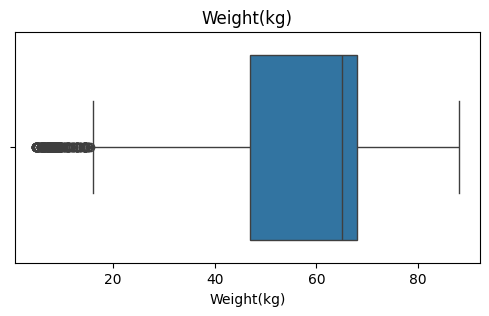

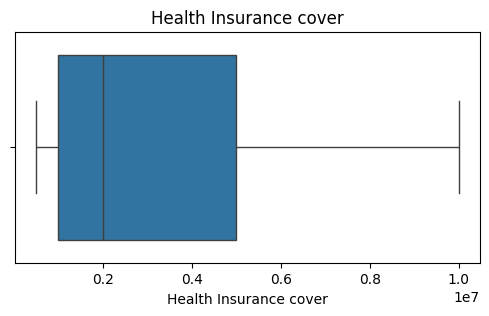

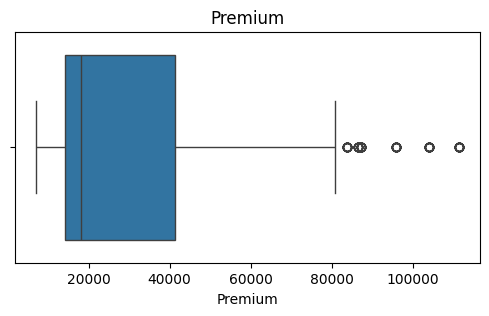

In [192]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [193]:
#4)Feature Engineering:
#first remove the columns which are not required

In [194]:
df.columns

Index(['Sr.no', 'Name', 'Age(yrs)', 'Gender', 'Height (cm)', 'Weight(kg)',
       'Health Insurance cover', 'Premium'],
      dtype='object')

In [195]:
df.drop(['Sr.no','Name'],inplace=True,axis=1)

In [196]:
#fill missing values
df['Height (cm)'].unique()

array([ 61.4 ,  63.9 ,  65.9 ,  67.6 ,  69.2 ,  70.6 ,  72.  ,  73.3 ,
        74.5 ,  95.3 , 102.5 , 109.2 , 115.7 , 122.  , 128.1 , 123.7 ,
       124.4 , 137.5 , 142.9 , 148.7 , 154.5 , 159.5 , 164.9 , 166.6 ,
       165.3 , 166.  , 167.  , 168.  , 165.  ,    nan,  56.  ,  58.  ,
        59.2 ,  61.5 ,  65.  ,  68.  ,  71.  ,  75.  ,  78.  ,  80.  ,
        87.2 ,  94.5 , 101.4 , 107.  , 112.8 , 118.3 , 122.3 , 123.4 ,
       137.8 , 143.1 , 148.2 , 152.2 , 153.5 , 154.2 , 153.8 , 152.4 ,
       154.  , 155.  ,  60.  ,  62.  ,  70.  ,  73.  ,  76.5 ,  88.  ,
        96.  , 102.  , 108.  , 113.  , 119.  , 123.  , 124.5 , 126.  ,
       128.  , 130.5 , 132.  , 135.  , 138.  , 142.  , 145.  , 150.  ,
       156.  , 160.  , 162.  ,  64.  ,  67.  ,  77.  ,  83.  ,  87.  ,
        89.  ,  93.  ,  99.5 , 105.  , 112.  , 125.  , 130.  , 136.  ,
       147.  , 148.  , 152.  , 153.  , 157.  , 158.  ,  72.5 ,  74.  ,
        75.5 , 108.5 , 113.5 , 119.3 ,  66.  ,  67.5 ,  69.  ,  71.8 ,
      

In [197]:
df['Height (cm)'] = df['Height (cm)'].fillna(
    df['Height (cm)'].median())

In [198]:
df['Weight(kg)'].unique()

array([ 6.4 ,  7.  ,  7.5 ,  7.9 ,  8.3 ,  8.6 ,  8.9 ,  9.2 ,  9.4 ,
       14.4 , 16.3 , 18.5 , 20.8 , 23.2 , 25.8 , 21.5 , 23.5 , 31.4 ,
       34.6 , 37.2 , 41.  , 45.7 , 50.9 , 54.  , 54.3 , 56.  , 58.  ,
       59.  , 60.  , 65.  , 70.  , 71.  , 73.  , 75.  , 77.  , 74.  ,
       72.  , 68.  , 69.  , 63.  ,  4.8 ,  5.2 ,  5.8 ,  6.11,  7.3 ,
        8.  ,  8.4 ,  9.1 ,  9.5 ,  9.6 , 11.1 , 12.9 , 14.5 , 16.  ,
       17.6 , 19.4 , 21.3 , 23.6 , 32.3 , 36.2 , 39.8 , 42.9 , 45.3 ,
       47.2 , 47.9 , 49.8 , 50.  , 48.  , 51.  , 67.  , 79.  , 85.  ,
         nan,  5.  ,  8.5 ,  9.  ,  9.8 , 10.2 , 10.5 , 11.  , 12.  ,
       13.5 , 15.  , 16.2 , 18.  , 19.5 , 21.2 , 25.  , 28.  , 31.  ,
       33.  , 35.5 , 38.  , 42.  , 46.  , 52.  , 62.  , 80.  , 82.  ,
       83.  , 84.  , 86.  , 88.  , 78.  , 76.  , 66.  , 64.  , 55.  ,
        6.5 , 17.  , 19.  , 23.  , 24.  , 26.  , 32.  , 35.  , 39.  ,
       43.  , 44.  , 45.  , 47.  , 49.  , 53.  , 57.  , 11.5 , 11.7 ,
       14.8 , 19.7 ,

In [199]:
df['Weight(kg)'] = df['Weight(kg)'].fillna(
    df['Weight(kg)'].median())

In [200]:
#convert text into numerical format
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age(yrs)                1676 non-null   float64
 1   Gender                  1676 non-null   object 
 2   Height (cm)             1676 non-null   float64
 3   Weight(kg)              1676 non-null   float64
 4   Health Insurance cover  1676 non-null   int64  
 5   Premium                 1676 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 78.7+ KB


In [201]:
df['Gender'].unique()

array(['male', 'female'], dtype=object)

In [202]:
df['Gender'].replace({'male':0,'female':1},inplace=True)

/tmp/ipykernel_498/1725639944.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({'male':0,'female':1},inplace=True)
/tmp/ipykernel_498/1725639944.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].replace({'male':0,'female':1},inplace=True)


In [203]:
df['Health Insurance cover'].unique()

array([  500000,   750000,  1000000,  1500000,  2000000,  2500000,
        5000000,  7500000, 10000000])

In [204]:
#find out the BMI using height and weight
df['BMI'] = df['Weight(kg)']/((df['Height (cm)']/100)**2)
df.drop(['Height (cm)','Weight(kg)'],axis=1,inplace=True)

In [205]:
#removing outliers:
df.columns

Index(['Age(yrs)', 'Gender', 'Health Insurance cover', 'Premium', 'BMI'], dtype='object')

<Axes: ylabel='Age(yrs)'>

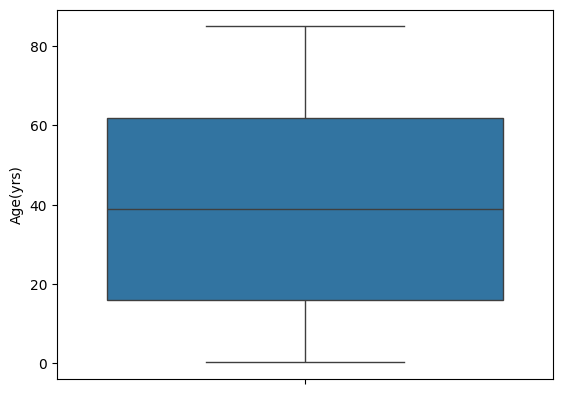

In [206]:
sns.boxplot(df['Age(yrs)'])


<Axes: ylabel='Health Insurance cover'>

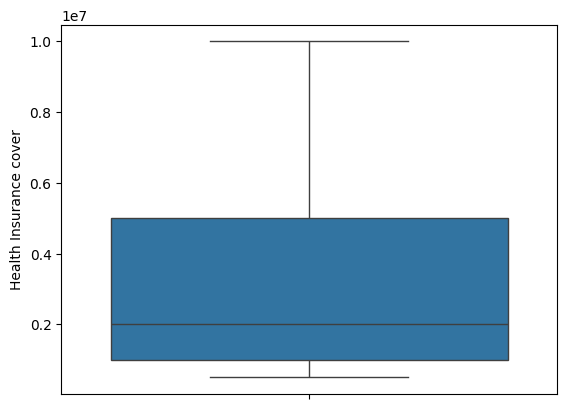

In [207]:
sns.boxplot(df['Health Insurance cover'])


<Axes: ylabel='Premium'>

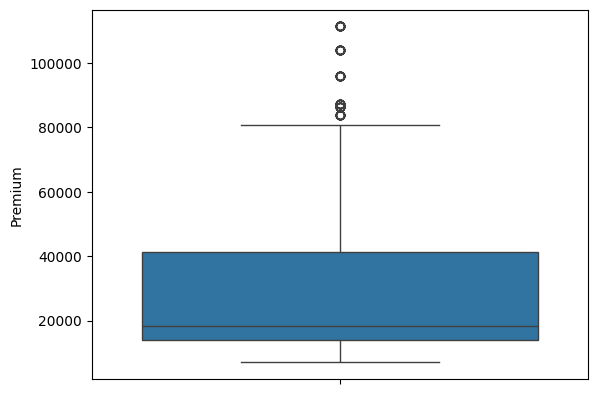

In [208]:
sns.boxplot(df['Premium'])


<Axes: ylabel='Premium'>

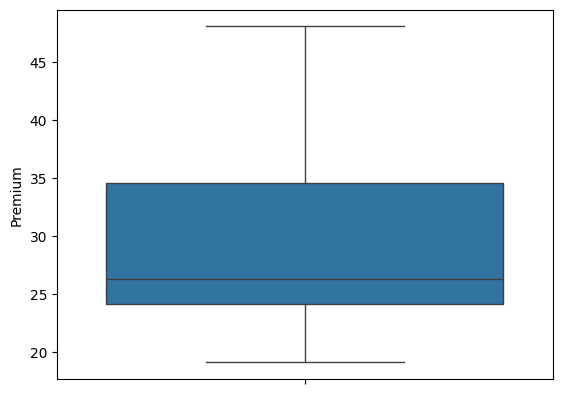

In [209]:
sns.boxplot(np.cbrt(df['Premium']))

<Axes: ylabel='BMI'>

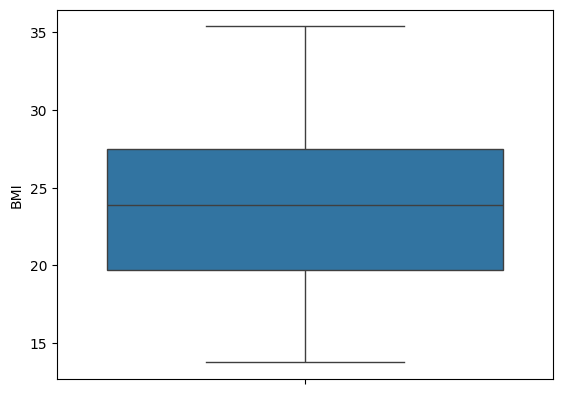

In [210]:
sns.boxplot(df['BMI'])


<Axes: >

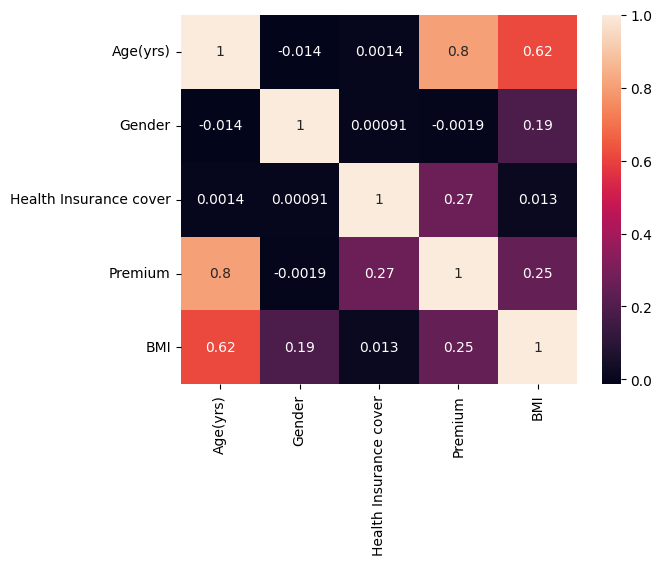

In [211]:
#5)feature selection:
df.corr()
sns.heatmap(df.corr(),annot=True)


In [212]:
x=df.drop(['Premium'],axis=1)
y=df['Premium']

In [213]:
#7)Model Buidling:
from sklearn.linear_model import LinearRegression

In [214]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.3)

In [215]:
linear_model=LinearRegression()

In [216]:
linear_model.fit(x_train,y_train)

LinearRegression()

In [217]:
y_pred=linear_model.predict(x_train)

In [218]:
mse=mean_squared_error(y_train,y_pred)
print(mse)

115514230.08867213


In [219]:
mae=mean_absolute_error(y_train,y_pred)
print(mae)

8150.092927382705


In [220]:
r2=r2_score(y_train,y_pred)
print(r2)


0.8219894882209786


In [221]:
y_pred=linear_model.predict(x_test)

In [222]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

103828434.46981017


In [223]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

7900.433844436255


In [224]:
r2_Score=r2_score(y_test,y_pred)
print(r2_Score)

0.8324585751408807


In [225]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

In [226]:
#standardization
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

In [227]:
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [228]:
knn_model = KNeighborsRegressor()
knn_model.fit(x_train_scaler, y_train)

KNeighborsRegressor()

In [229]:
y_pred = knn_model.predict(x_train_scaler)

In [230]:
mse=mean_squared_error(y_train,y_pred)
print(mse)

10321742.815004263


In [231]:
mae=mean_absolute_error(y_train,y_pred)
print(mae)

1489.5873827791986


In [232]:
r2=r2_score(y_train,y_pred)
print(r2)

0.9840939188224695


In [233]:
y_pred = knn_model.predict(x_test_scaler)

In [234]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

9862288.129224652


In [235]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

1857.1749502982107


In [236]:
r2=r2_score(y_test,y_pred)
print(r2)

0.9840858449423898


In [237]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [238]:
knn_model = KNeighborsRegressor()
knn_model.fit(x_train_scaled, y_train)

KNeighborsRegressor()

In [239]:
y_pred = knn_model.predict(x_train_scaled)

In [240]:
mse=mean_squared_error(y_train,y_pred)
print(mse)

10003385.740835465


In [241]:
mae=mean_absolute_error(y_train,y_pred)
print(mae)

1418.6973572037512


In [242]:
R2_score=r2_score(y_train,y_pred)
print(R2_score)

0.9845845155710932


In [243]:
y_pred = knn_model.predict(x_test_scaled)

In [244]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

9765704.16500994


In [245]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

1756.0258449304174


In [246]:
R2_score=r2_score(y_test,y_pred)
print(R2_score)

0.9842416964205105


In [247]:
from sklearn.tree import DecisionTreeRegressor,plot_tree

In [248]:
dt_model=DecisionTreeRegressor(random_state=1)

In [249]:
dt_model.fit(x_train,y_train)

DecisionTreeRegressor(random_state=1)

In [250]:
y_pred=dt_model.predict(x_train)

In [251]:
mse=mean_squared_error(y_train,y_pred)
print(mse)

0.0


In [252]:
mae=mean_absolute_error(y_train,y_pred)
print(mae)

0.0


In [253]:
R2_Score=r2_score(y_train,y_pred)
print(R2_Score)

1.0


In [254]:
y_pred=dt_model.predict(x_test)

In [255]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

197624.25447316104


In [256]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

28.031809145129223


In [257]:
R2_Score=r2_score(y_test,y_pred)
print(R2_Score)

0.9996811061502542


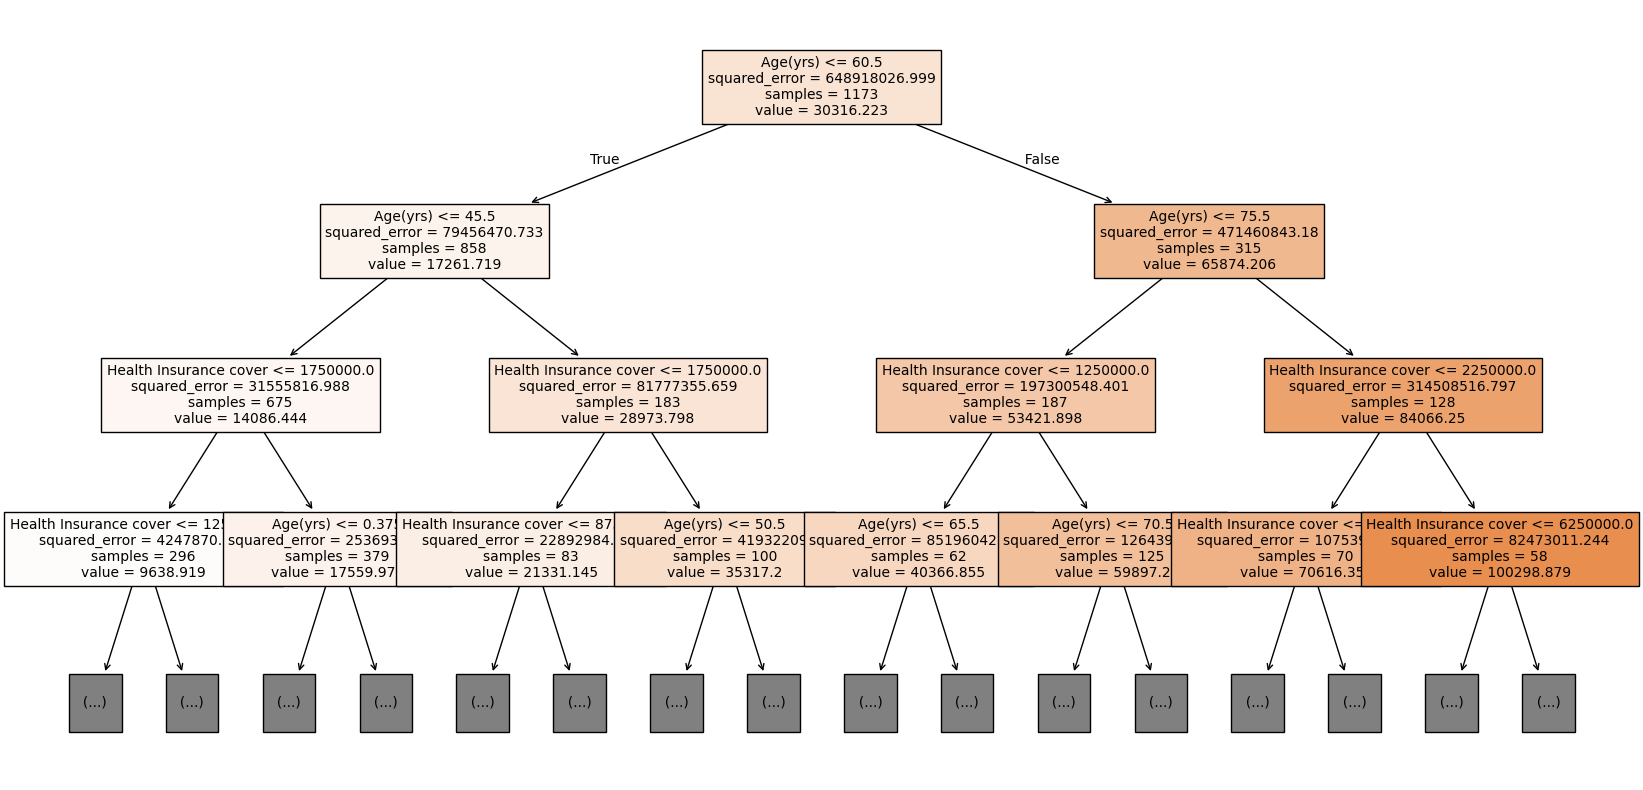

In [258]:
plt.figure(figsize=(20,10))
plot_tree(dt_model,feature_names=x.columns,filled=True,max_depth=3,fontsize=10)
plt.savefig('DECISION TREE_png')




In [259]:
from sklearn.ensemble import RandomForestRegressor

In [260]:
rf_model=RandomForestRegressor()

In [261]:
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [262]:
y_pred=rf_model.predict(x_train)

In [263]:
mse=mean_squared_error(y_train,y_pred)
print(mse)

793708.6818840579


In [264]:
mae=mean_absolute_error(y_train,y_pred)
print(mae)

127.79317988064791


In [265]:
r2_Score=r2_score(y_train,y_pred)
print(r2_Score)

0.9987768737361866


In [266]:
y_pred=rf_model.predict(x_test)

In [267]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

2231645.31418489


In [268]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

247.67972166998013


In [269]:
r2_Score=r2_score(y_test,y_pred)
print(r2_Score)

0.9963989340913406


In [274]:
results = pd.DataFrame({'   Model     ':['Linear Regression','KNN StandardScaler','KNN MinMaxScaler','Decision Tree','Random Forest'],
                       'Train Accuracy':[82.19,98.40,98.45,100,99.87],
                      'Test Accuracy':[79,98.40,98.42,99,99.63]})
print(results)

           Model       Train Accuracy  Test Accuracy
0   Linear Regression           82.19          79.00
1  KNN StandardScaler           98.40          98.40
2    KNN MinMaxScaler           98.45          98.42
3       Decision Tree          100.00          99.00
4       Random Forest           99.87          99.63
